In [1]:
import pickle
from pathlib import Path
import numpy as onp

print("Importing JAX")
import jax
import jax.numpy as np
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platforms", 'cpu')
jax.config.update("jax_traceback_filtering", 'off')
print("Importing JAX successful")

from bilby.gw.result import CBCResult
from bilby.gw import WaveformGenerator, GravitationalWaveTransient
from bilby.gw.source import lal_binary_black_hole
from bilby.gw.detector import InterferometerList
from bilby.gw.conversion import convert_to_lal_binary_black_hole_parameters

# Jim imports
from jimgw.core.single_event.data import Data, PowerSpectrum
from jimgw.core.single_event.detector import get_H1, get_L1
from jimgw.core.single_event.likelihood import BaseTransientLikelihoodFD
from jimgw.core.single_event.waveform import RippleIMRPhenomPv2

## We load in the pickle dump from the bilby run
indir = Path('/home/user/ckng/project/jim_GWTC3/src/static/bilby_runs/outdir/GW170608/')
with open(indir / 'data/GW170608_data0_1180922494-5_generation_data_dump.pickle', 'rb') as pickled_data:
    bilby_gen_data = pickle.load(pickled_data)
    print(bilby_gen_data)
bilby_result = CBCResult.from_hdf5(
    indir / 'result/GW170608_data0_1180922494-5_analysis_H1L1_result.hdf5'
)
bilby_prior = bilby_result.priors

trigger_time = bilby_gen_data.trigger_time
duration = float(bilby_gen_data.meta_data['command_line_args']['duration'])
post_trigger_duration = float(bilby_gen_data.meta_data['command_line_args']['post_trigger_duration'])
start_time = trigger_time + post_trigger_duration - duration


# Get maxL parameters for the geocent_time reference
maxL_idx = bilby_result.posterior['log_likelihood'].idxmax()
maxL_params = bilby_result.posterior.iloc[maxL_idx]

likelihood_kwargs = bilby_result.meta_data['likelihood']

injection_params_keys = ["mass_1", "mass_2", "a_1", "a_2", "tilt_1", "tilt_2", "phi_12", "phi_jl", "luminosity_distance", "theta_jn", "psi", "phase", "geocent_time", "ra", "dec"]
bilby_inj_params = {key: maxL_params[key] for key in injection_params_keys}

bilby_ifos = bilby_gen_data.interferometers

for ifo in bilby_ifos:
    ifo.minimum_frequency = 30.0

bilby_waveform_generator = WaveformGenerator(
    duration=duration,
    sampling_frequency=likelihood_kwargs['sampling_frequency'],
    frequency_domain_source_model=lal_binary_black_hole,
    waveform_arguments=likelihood_kwargs['waveform_arguments'],
    parameter_conversion=convert_to_lal_binary_black_hole_parameters
)

bilby_ifos.set_strain_data_from_zero_noise(
    sampling_frequency=likelihood_kwargs['sampling_frequency'],
    duration=duration,
    start_time=start_time)

# Inject the signal into the interferometers
bilby_ifos.inject_signal(
    waveform_generator=bilby_waveform_generator,
    parameters=bilby_inj_params
)


likelihood_bilby = GravitationalWaveTransient(
    interferometers=bilby_ifos,
    waveform_generator=bilby_waveform_generator,
    time_marginalization=False,
    phase_marginalization=False,
    distance_marginalization=False,
    reference_frame=likelihood_kwargs['reference_frame'],
    jitter_time=False,
    priors=bilby_prior.copy(),
)

likelihood_bilby.parameters = bilby_inj_params.copy()
bilby_log_l = likelihood_bilby.log_likelihood_ratio()
print(f"Bilby likelihood with injected data: {bilby_log_l}")

# SET UP JIM IFOS WITH THE INJECTED DATA

jim_ifos = [get_H1(), get_L1()]
f_mins = np.array([ifo.minimum_frequency for ifo in bilby_ifos])
f_maxs = np.array([ifo.maximum_frequency for ifo in bilby_ifos])
f_min, f_max = np.max(f_mins), np.min(f_maxs)


strain_start_time = bilby_ifos[0].strain_data.start_time

for i, jim_ifo in enumerate(jim_ifos):
    bilby_ifo = bilby_ifos[i]
    assert bilby_ifo.name == jim_ifo.name, f"{bilby_ifo.name = } != {jim_ifo.name = }"

    injected_fd_data = bilby_ifo.frequency_domain_strain
    
    jim_data = Data.from_fd(
        fd=injected_fd_data,
        frequencies=bilby_ifo.frequency_array,
        epoch=strain_start_time,
        name=bilby_ifo.name + '_fd_data_injected',
    )

    # Use the same PSD as Bilby
    jim_psd = PowerSpectrum(
        values=bilby_ifo.power_spectral_density_array,
        frequencies=bilby_ifo.frequency_array,
        name=jim_ifo.name + '_psd',
    )

    jim_ifo.frequency_bounds = (bilby_ifo.minimum_frequency, bilby_ifo.maximum_frequency)
    jim_ifo.set_data(jim_data)
    jim_ifo.set_psd(jim_psd)


reference_frequency = float(bilby_gen_data.meta_data['command_line_args']['reference_frequency'])
jim_Pv2 = RippleIMRPhenomPv2(f_ref=reference_frequency)


# Jim likelihood
keys = ["chirp_mass", "symmetric_mass_ratio", "spin_1x", "spin_1y", "spin_1z", "spin_2x", "spin_2y", "spin_2z", "iota", "luminosity_distance", "phase", "psi", "ra", "dec"]
jim_keys = ["M_c", "eta", "s1_x", "s1_y", "s1_z", "s2_x", "s2_y", "s2_z", "iota", "d_L", "phase_c", "psi", "ra", "dec"]
jim_to_bilby_map = dict(zip(jim_keys, keys))
bilby_to_jim_map = dict(zip(keys, jim_keys))

maxL_jim_params = {key: maxL_params[jim_to_bilby_map[key]] for key in jim_keys}
maxL_jim_params['t_c'] = maxL_params['geocent_time'] - trigger_time

jim_likelihood = BaseTransientLikelihoodFD(
    jim_ifos, waveform=jim_Pv2, 
    f_min=f_min, f_max=f_max,
    trigger_time=trigger_time, 
)

jim_log_l = jim_likelihood.evaluate(maxL_jim_params, None)
print(f"Jim likelihood: {jim_log_l}")

print(f"\nDifference (Bilby-jim): {bilby_log_l - jim_log_l}")

Importing JAX
Importing JAX successful


/home/user/smwong/.local/lib/python3.11/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


13:07 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
13:07 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
13:07 bilby INFO    : Injected signal in H1:
13:07 bilby INFO    :   optimal SNR = 12.81
13:07 bilby INFO    :   matched filter SNR = 12.81+0.00j
13:07 bilby INFO    :   mass_1 = 12.893065693168529
13:07 bilby INFO    :   mass_2 = 7.496470546703308
13:07 bilby INFO    :   a_1 = 0.46218869092222137
13:07 bilby INFO    :   a_2 = 0.5568113305083952
13:07 bilby INFO    :   tilt_1 = 0.9585574793152598
13:07 bilby INFO    :   tilt_2 = 2.16465087124126

Bilby likelihood with injected data: 119.96600998886866
Jim likelihood: 119.96599939195306

Difference (Bilby-jim): 1.059691560101328e-05


In [2]:
n_samples = 50
samples_bilby = bilby_result.posterior.sample(n_samples, random_state=42)

jim_keys = ["M_c", "eta", "s1_x", "s1_y", "s1_z", "s2_x", "s2_y", "s2_z", "iota", "d_L", "phase_c", "psi", "ra", "dec"]
keys = ["chirp_mass", "symmetric_mass_ratio", "spin_1x", "spin_1y", "spin_1z", "spin_2x", "spin_2y", "spin_2z", "iota", "luminosity_distance", "phase", "psi", "ra", "dec"]
jim_to_bilby_map = dict(zip(jim_keys, keys))

param_list = []
for i in range(n_samples):
    sample = samples_bilby.iloc[i].to_dict()
    
    likelihood_bilby.parameters = sample.copy()
    logL_bilby = likelihood_bilby.log_likelihood_ratio()
    
    jim_params = {key: sample[jim_to_bilby_map[key]] for key in jim_keys}
    jim_params["t_c"] = sample["geocent_time"] - trigger_time
    logL_jim = jim_likelihood.evaluate(jim_params, None)
    
    param_list.append((*jim_params.values(), logL_jim, logL_bilby))

bilby_Ls, jim_normal_Ls = zip(*[(row[-1], row[-2]) for row in param_list])
bilby_Ls = np.array(bilby_Ls)
jim_normal_Ls = np.array(jim_normal_Ls)
diff = bilby_Ls - jim_normal_Ls


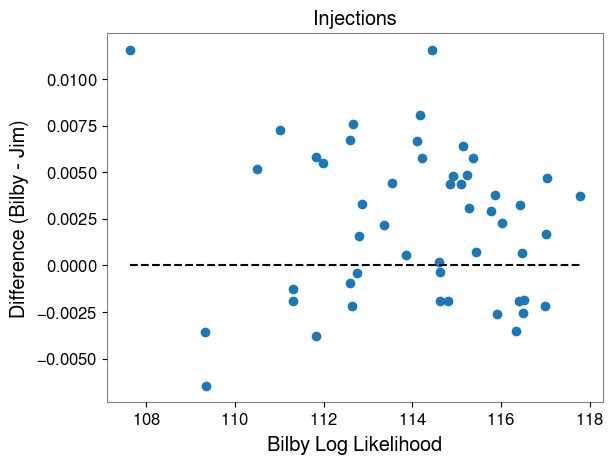

In [3]:
# plot scatter plot 
import matplotlib.pyplot as plt
plt.scatter(bilby_Ls, diff)
plt.hlines(0, color='k', xmin=min(bilby_Ls), xmax=max(bilby_Ls), linestyle='--')
plt.xlabel("Bilby Log Likelihood")
plt.ylabel("Difference (Bilby - Jim)")
plt.title("Injections")
plt.grid()
plt.show()